# Readout Charge-Gate Power with Reference — Analyzer Development
Prototype a new analyzer step by step.  
Load a pre-parsed `xarray.Dataset` from an `.h5` file and explore the raw data.

In [11]:

import xarray as xr
import matplotlib.pyplot as plt
from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.parsers.qualibrate_parser import repetition_data
import numpy as np

## 1. Configuration

In [12]:
import os

# Path to the pre-parsed xarray Dataset stored as NetCDF4/HDF5
H5_PATH = r"d:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q2\ng01_ref0126_test04\square\ro_charge_power_post_selected.h5"

# Optional: paths for saving outputs (set to None to skip saving)
METADATA_SAVE_PATH = None   # e.g. r"output/state_disc_results.pkl"
FIGURE_SAVE_PATH   = os.path.join(os.path.dirname(H5_PATH), "figures")
os.makedirs(FIGURE_SAVE_PATH, exist_ok=True)
# Optional analysis kwargs
ANALYSIS_KWARGS = {
    # "user_mean": [[0.1, 0.2], [0.3, 0.4]],  # initial guess for GMM centers
    # "user_std": 0.05,                         # initial guess for Gaussian std
    "outlier_sigma": 3,                       # outlier detection threshold
}

## 2. Load Dataset

In [13]:
sq_data = load_xarray_h5(H5_PATH)
sq_data

<xarray.Dataset> Size: 36MB
Dimensions:         (prepared_state: 2, charge_gate: 49, amp_prefactor: 20,
                     shot_idx: 380)
Coordinates:
  * charge_gate     (charge_gate) float64 392B 0.0 0.01 0.02 ... 0.46 0.47 0.48
  * amp_prefactor   (amp_prefactor) float64 160B 0.0 0.1 0.2 0.3 ... 1.7 1.8 1.9
  * prepared_state  (prepared_state) int32 8B 0 1
    qubit           object 8B 'q1'
  * shot_idx        (shot_idx) int64 3kB 0 1 2 3 4 5 ... 374 375 376 377 378 379
Data variables:
    I1_1            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    I1_2            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    I1_3            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    Q1_1            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    Q1_2            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    Q1_3            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    outlier_mask    (prepared_state, charge_gate, amp_prefactor, shot_idx) bool 745kB ...
Attributes:
    mean:     [ 0.00015317 -0.00067999]
    std:      0.0005526675398603853

## 3. Explore Dataset Structure
Inspect dimensions, coordinates, variables, and attributes.

In [14]:

print("=== Dimensions ===")
print(sq_data.dims)
print("\n=== Coordinates ===")
for name, coord in sq_data.coords.items():
    print(f"  {name}: shape={coord.shape}, dtype={coord.dtype}, values={coord.values if coord.size < 20 else f'[{coord.values[0]} ... {coord.values[-1]}] (len={coord.size})'}")
print("\n=== Data Variables ===")
for name, var in sq_data.data_vars.items():
    print(f"  {name}: shape={var.shape}, dims={var.dims}, dtype={var.dtype}")
print("\n=== Attributes ===")
for k, v in sq_data.attrs.items():
    print(f"  {k}: {v}")

=== Dimensions ===
FrozenMappingWarningOnValuesAccess({'prepared_state': 2, 'charge_gate': 49, 'amp_prefactor': 20, 'shot_idx': 380})

=== Coordinates ===
  charge_gate: shape=(49,), dtype=float64, values=[0.0 ... 0.48] (len=49)
  amp_prefactor: shape=(20,), dtype=float64, values=[0.0 ... 1.9] (len=20)
  prepared_state: shape=(2,), dtype=int32, values=[0 1]
  qubit: shape=(), dtype=object, values=q1
  shot_idx: shape=(380,), dtype=int64, values=[0 ... 379] (len=380)

=== Data Variables ===
  I1_1: shape=(2, 49, 20, 380), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  I1_2: shape=(2, 49, 20, 380), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  I1_3: shape=(2, 49, 20, 380), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  Q1_1: shape=(2, 49, 20, 380), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  Q1_2: shape=(2, 49, 20, 380), dims=('prepar

In [15]:
# Check if outlier_mask exists in the dataset
print("Looking for outlier_mask in dataset...")
if 'outlier_mask' in sq_data.data_vars:
    print("Found outlier_mask!")
    print(f"outlier_mask shape: {sq_data['outlier_mask'].shape}")
    print(f"outlier_mask dims: {sq_data['outlier_mask'].dims}")
    print(f"Number of outliers: {sq_data['outlier_mask'].sum().values}")
    print(f"Percentage of outliers: {100 * sq_data['outlier_mask'].mean().values:.2f}%")
else:
    print("No outlier_mask found in dataset.")
    print("Available data variables:")
    for var_name in sq_data.data_vars:
        print(f"  - {var_name}")

Looking for outlier_mask in dataset...
Found outlier_mask!
outlier_mask shape: (2, 49, 20, 380)
outlier_mask dims: ('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx')
Number of outliers: 31478
Percentage of outliers: 4.23%


In [16]:
from scqat.protocols.single_state_outlier import SingleStateOutlierAnalyzer

# Stack all dims except prepared_state into a flat shot_idx, one dataset per prepared_state
# Pre-filter by existing outlier_mask (drop shots where outlier_mask is True)
dims_to_stack = [d for d in sq_data['I1_3'].dims if d != 'prepared_state']
outlier_datasets = {}
for state in sq_data.coords['prepared_state'].values:
    subset = sq_data[['I1_3', 'Q1_3', 'outlier_mask']].sel(prepared_state=state)
    mask_flat = subset['outlier_mask'].values.ravel()
    I_flat = subset['I1_3'].values.ravel()[~mask_flat]
    Q_flat = subset['Q1_3'].values.ravel()[~mask_flat]
    ds = xr.Dataset(
        {'I': ('shot_idx', I_flat), 'Q': ('shot_idx', Q_flat)},
        coords={'shot_idx': np.arange(len(I_flat))},
    )
    outlier_datasets[int(state)] = ds
    print(f"prepared_state={state}: {len(I_flat)} shots (dropped {mask_flat.sum()} outliers)")

# Run SingleStateOutlierAnalyzer on each prepared_state
analyzer = SingleStateOutlierAnalyzer()
outlier_results = {}
for state, ds in outlier_datasets.items():
    print(f"--- Analyzing prepared_state={state} ---")
    result = analyzer.analyze(ds, **ANALYSIS_KWARGS)
    outlier_results[state] = result

prepared_state=0: 359345 shots (dropped 13055 outliers)
prepared_state=1: 353977 shots (dropped 18423 outliers)
--- Analyzing prepared_state=0 ---
--- Analyzing prepared_state=1 ---


Prepared state: 0
fitted_paras: {'mean': array([[ 0.00013333, -0.00067849]]), 'sigma_x': 0.0005605073624099788, 'sigma_y': 0.0005605073624099788, 'std': 0.0005605073624099788, 'amp': 430825.8817259511, 'offset': 0.0}


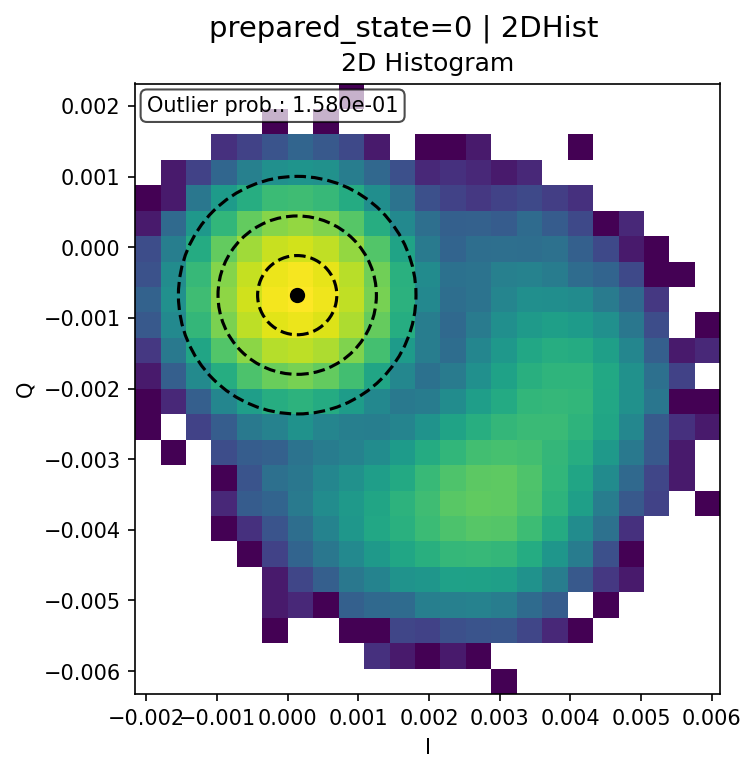

Prepared state: 1
fitted_paras: {'mean': array([[ 0.00339483, -0.00049474]]), 'sigma_x': 0.0005879300797297926, 'sigma_y': 0.0005879300797297926, 'std': 0.0005879300797297926, 'amp': 298214.926925615, 'offset': 0.0}


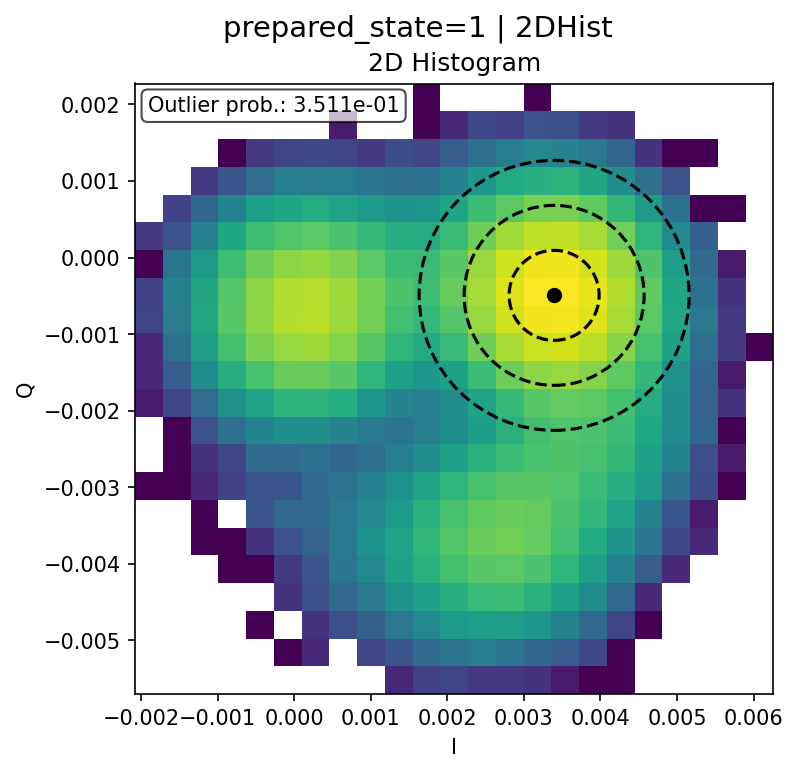

In [17]:
# Display figures from SingleStateOutlierAnalyzer results
for state, (params, figs) in outlier_results.items():
    print(f"Prepared state: {state}")
    print(f"fitted_paras: {params['fitted_paras']}")
    for fig_name, fig in figs.items():
        fig.suptitle(f"prepared_state={state} | {fig_name}", fontsize=14, y=1.02)
        display(fig)
        plt.close(fig)

In [18]:
outlier_sigma = ANALYSIS_KWARGS.get('outlier_sigma', 3)
charge_vals = sq_data.coords['charge_gate'].values
amp_vals = sq_data.coords['amp_prefactor'].values
prepared_states = sq_data.coords['prepared_state'].values
grid_shape = (len(prepared_states), len(amp_vals), len(charge_vals))
grid_dims = ['prepared_state', 'amp_prefactor', 'charge_gate']
grid_coords = {'prepared_state': prepared_states, 'amp_prefactor': amp_vals, 'charge_gate': charge_vals}

# Initialize result arrays for set_3 and set_2
results_3 = {k: np.full(grid_shape, np.nan) for k in ['outlier_probability', 'I_mean', 'Q_mean', 'std']}
results_2 = {k: np.full(grid_shape, np.nan) for k in ['outlier_probability', 'I_mean', 'Q_mean', 'std']}

# Per-grid-point outlier detection for set_3 (fixed fit from global parameters)
not_maps_3 = {}
for si, state in enumerate(prepared_states):
    params_global, _ = outlier_results[int(state)]
    fixed_mean = params_global['fitted_paras']['mean'][0]
    fixed_std = params_global['fitted_paras']['std']

    subset = sq_data[['I1_3', 'Q1_3', 'outlier_mask']].sel(prepared_state=state)

    for ci, cg in enumerate(charge_vals):
        for ai, ap in enumerate(amp_vals):
            cell = subset.sel(charge_gate=cg, amp_prefactor=ap)
            mask = cell['outlier_mask'].values.ravel()
            valid_idx = ~mask
            if valid_idx.sum() == 0:
                continue
            I_valid = cell['I1_3'].values.ravel()[valid_idx]
            Q_valid = cell['Q1_3'].values.ravel()[valid_idx]
            ds = xr.Dataset(
                {'I': ('shot_idx', I_valid), 'Q': ('shot_idx', Q_valid)},
                coords={'shot_idx': np.arange(len(I_valid))},
            )
            result, _ = analyzer.analyze(
                ds, skip_figures=True,
                fixed_mean=fixed_mean, fixed_std=fixed_std,
                outlier_sigma=outlier_sigma,
            )
            results_3['outlier_probability'][si, ai, ci] = result['outlier_probability']
            results_3['I_mean'][si, ai, ci] = result['fitted_paras']['mean'][0][0]
            results_3['Q_mean'][si, ai, ci] = result['fitted_paras']['mean'][0][1]
            results_3['std'][si, ai, ci] = result['fitted_paras']['std']

    label = f"not_{int(state)}"
    not_maps_3[label] = xr.DataArray(
        results_3['outlier_probability'][si], dims=['amp_prefactor', 'charge_gate'],
        coords={'amp_prefactor': amp_vals, 'charge_gate': charge_vals},
    )

# Per-grid-point outlier detection for set_2 (free fit per grid cell)
not_maps_2 = {}
for si, state in enumerate(prepared_states):
    subset = sq_data[['I1_2', 'Q1_2', 'outlier_mask']].sel(prepared_state=state)

    for ci, cg in enumerate(charge_vals):
        for ai, ap in enumerate(amp_vals):
            cell = subset.sel(charge_gate=cg, amp_prefactor=ap)
            mask = cell['outlier_mask'].values.ravel()
            valid_idx = ~mask
            if valid_idx.sum() < 10:
                continue
            I_valid = cell['I1_2'].values.ravel()[valid_idx]
            Q_valid = cell['Q1_2'].values.ravel()[valid_idx]
            ds = xr.Dataset(
                {'I': ('shot_idx', I_valid), 'Q': ('shot_idx', Q_valid)},
                coords={'shot_idx': np.arange(len(I_valid))},
            )
            try:
                result, _ = analyzer.analyze(
                    ds, skip_figures=True,
                    outlier_sigma=outlier_sigma,
                )
                results_2['outlier_probability'][si, ai, ci] = result['outlier_probability']
                results_2['I_mean'][si, ai, ci] = result['fitted_paras']['mean'][0][0]
                results_2['Q_mean'][si, ai, ci] = result['fitted_paras']['mean'][0][1]
                results_2['std'][si, ai, ci] = result['fitted_paras']['std']
            except Exception as e:
                print(f"  Fit failed at cg={cg}, ap={ap}, state={state}: {e}")
                continue

    label = f"not_{int(state)}"
    not_maps_2[label] = xr.DataArray(
        results_2['outlier_probability'][si], dims=['amp_prefactor', 'charge_gate'],
        coords={'amp_prefactor': amp_vals, 'charge_gate': charge_vals},
    )

# Assemble result dataset
result_ds = xr.Dataset(
    {f"{var}_set{s}": (grid_dims, data)
     for s, res in [('3', results_3), ('2', results_2)]
     for var, data in res.items()},
    coords=grid_coords,
    attrs=sq_data.attrs,
)
result_ds.attrs['outlier_sigma'] = outlier_sigma
print(result_ds)


<xarray.Dataset> Size: 126kB
Dimensions:                   (prepared_state: 2, amp_prefactor: 20,
                               charge_gate: 49)
Coordinates:
  * prepared_state            (prepared_state) int32 8B 0 1
  * amp_prefactor             (amp_prefactor) float64 160B 0.0 0.1 ... 1.8 1.9
  * charge_gate               (charge_gate) float64 392B 0.0 0.01 ... 0.47 0.48
Data variables:
    outlier_probability_set3  (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    I_mean_set3               (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    Q_mean_set3               (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    std_set3                  (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    outlier_probability_set2  (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    I_mean_set2               (prepared_state, amp_prefactor, charge_gate) float64 16kB ...
    Q_mean_set2               (prepared_state, amp_pre

Saved to d:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q2\ng01_ref0126_test04\square\figures\outlier_fraction_state_0.png


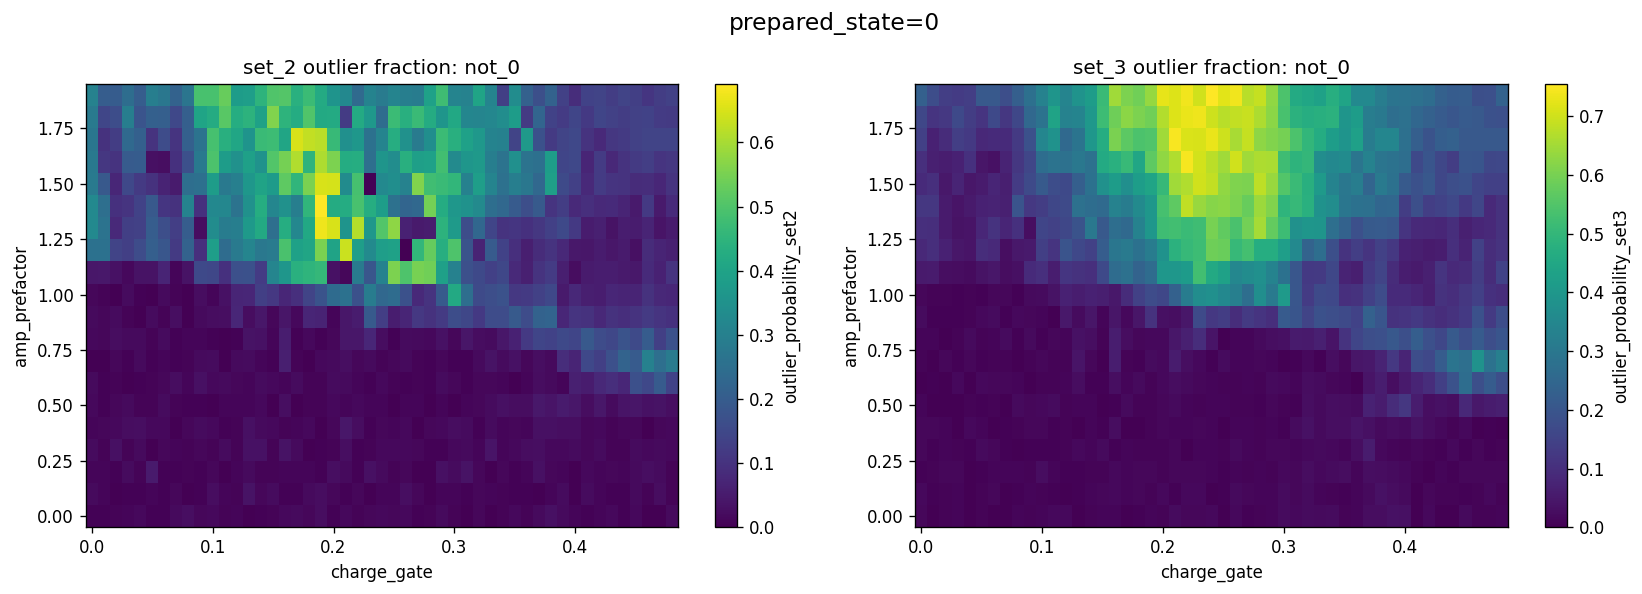

Saved to d:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q2\ng01_ref0126_test04\square\figures\outlier_fraction_state_1.png


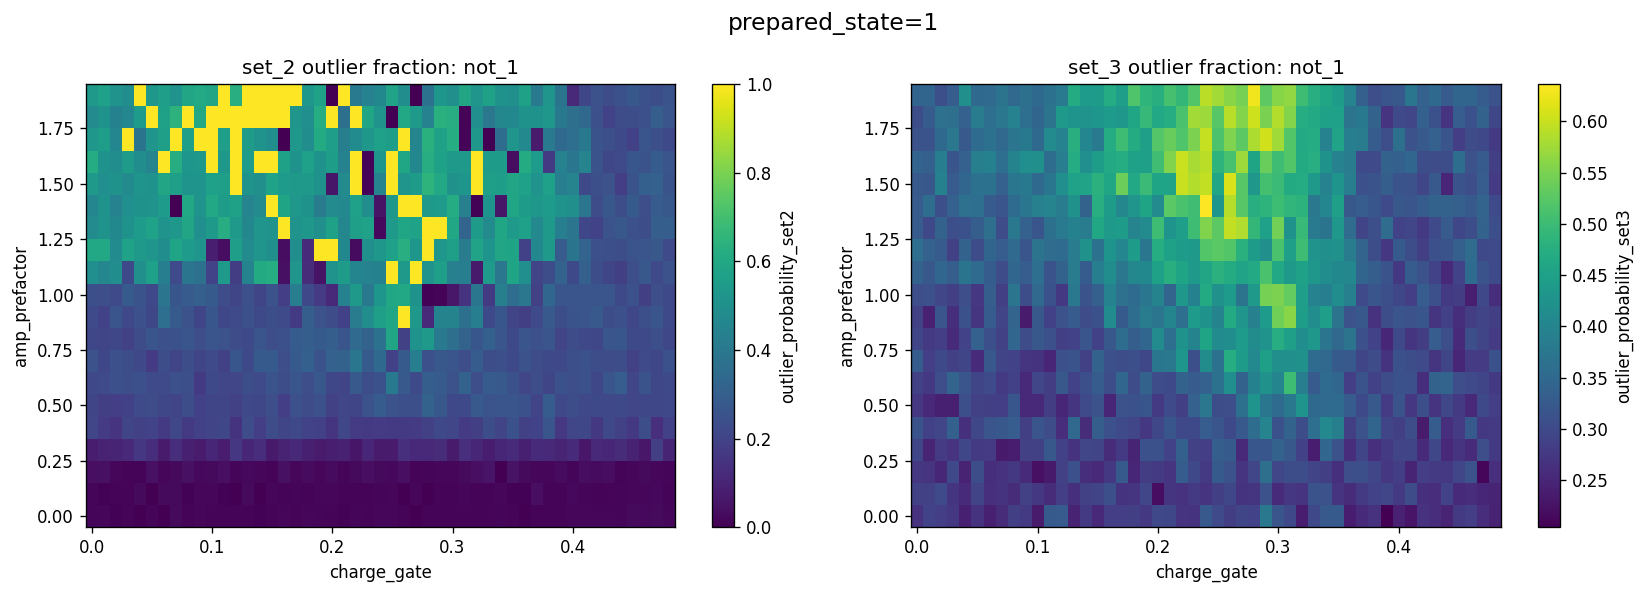

In [19]:
# Plot outlier fraction: one figure per prepared_state, set_2 (left) and set_3 (right)
for state in result_ds.coords['prepared_state'].values:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

    result_ds['outlier_probability_set2'].sel(prepared_state=state).plot.pcolormesh(
        ax=axes[0], x='charge_gate', y='amp_prefactor',
        cmap='viridis', add_colorbar=True,
    )
    axes[0].set_title(f"set_2 outlier fraction: not_{int(state)}")

    result_ds['outlier_probability_set3'].sel(prepared_state=state).plot.pcolormesh(
        ax=axes[1], x='charge_gate', y='amp_prefactor',
        cmap='viridis', add_colorbar=True,
    )
    axes[1].set_title(f"set_3 outlier fraction: not_{int(state)}")

    fig.suptitle(f"prepared_state={int(state)}", fontsize=14)
    fig.tight_layout()
        
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, f"outlier_fraction_state_{int(state)}.png"), bbox_inches='tight')
    print(f"Saved to {os.path.join(FIGURE_SAVE_PATH, f'outlier_fraction_state_{int(state)}.png')}")
    plt.show()

In [20]:
# Save result dataset to the same folder as H5_PATH
save_path = os.path.join(os.path.dirname(H5_PATH), "outlier_results.h5")
result_ds.to_netcdf(save_path, engine='h5netcdf')
print(f"Saved result dataset to {save_path}")

Saved result dataset to d:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q2\ng01_ref0126_test04\square\outlier_results.h5
